# TASK 05 — Eigenvectors and PCA, One More Time

In this task, we connect eigen-decomposition and Singular Value Decomposition
(SVD) to Principal Component Analysis (PCA).

We will:

1. Generate a 2D correlated dataset.
2. Compute its covariance matrix.
3. Find the covariance eigenvectors and eigenvalues.
4. Visualize the principal directions.
5. Find the same directions using SVD.
6. Compare the eigenvectors with the right singular vectors.
7. Project the 2D data onto the first principal component.
8. Reduce the data from 2D to 1D.
9. Calculate how much of the data's variance is retained.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn


In [3]:
np.random.seed(42)
x = np.random.normal(0,1,500)
noise = np.random.normal(0,0.4,500)
y = 2 * x + noise
data = np.column_stack((x,y))
print("Data Shape:",data.shape)
print("\nFirst 5 data points:")
print(data[:5])

Data Shape: (500, 2)

First 5 data points:
[[ 0.49671415  1.36389933]
 [-0.1382643   0.48723805]
 [ 0.64768854  0.73595005]
 [ 1.52302986  3.27124741]
 [-0.23415337 -0.72856378]]


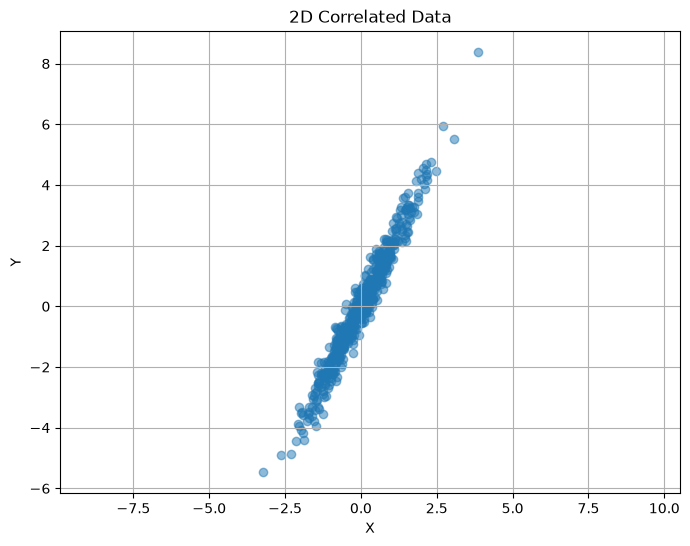

In [4]:
plt.figure(figsize=(8,6))

plt.scatter(
    data[:,0],
    data[:,1],
    alpha=0.5
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("2D Correlated Data")

plt.grid(True)
plt.axis("equal")

plt.show()


In [5]:
mean = data.mean(axis=0)

centred = data - mean

print("Mean of original data:")
print(mean)

print("\nMean of centred data:")
print(centred.mean(axis=0))

Mean of original data:
[0.00683799 0.02640644]

Mean of centred data:
[ 3.15303339e-17 -4.44089210e-18]


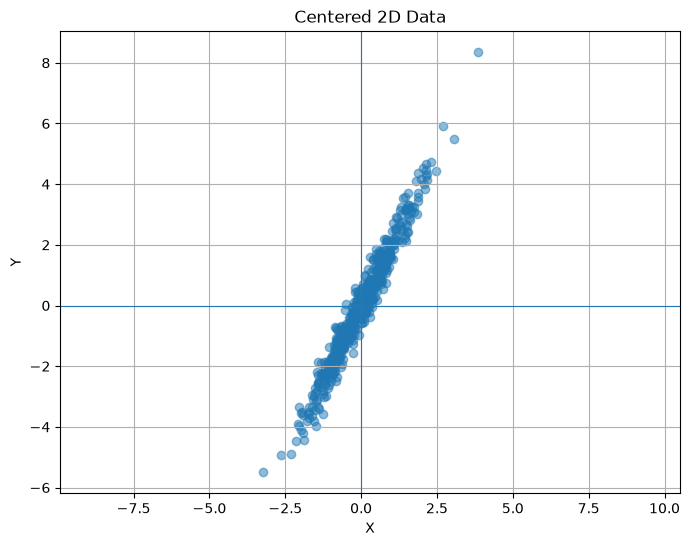

In [6]:
plt.figure(figsize=(8, 6))

plt.scatter(
    centred[:, 0],
    centred[:, 1],
    alpha=0.5
)

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Centered 2D Data")

plt.grid(True)
plt.axis("equal")

plt.show()

In [7]:
cov = np.cov(data.T)


cov = np.cov(data.T)

print("Covariance matrix:")
print(cov)

Covariance matrix:
[[0.96285794 1.89666851]
 [1.89666851 3.88827884]]


### Covariance Matrix

The covariance matrix tells us how the features vary together.

For a 2D dataset:

    [[Var(X), Cov(X,Y)],
     [Cov(X,Y), Var(Y)]]

The diagonal contains the variance of each feature.

The off-diagonal values represent how the two features vary together.

Because our X and Y are strongly correlated, the covariance values are
large and positive.

In [8]:
eigenvalues, eigenvectors = np.linalg.eig(cov)

print("Eigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)

Eigenvalues:
[0.0303913 +0.j 4.82074548+0.j]

Eigenvectors:
[[-0.89741013+0.j -0.44119729+0.j]
 [ 0.44119729+0.j -0.89741013+0.j]]


In [15]:
order = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

print("Sorted eigenvalues:")
print(eigenvalues)

print("\nSorted eigenvectors:")
print(eigenvectors)

Sorted eigenvalues:
[4.82074548+0.j 0.0303913 +0.j]

Sorted eigenvectors:
[[-0.44119729+0.j -0.89741013+0.j]
 [-0.89741013+0.j  0.44119729+0.j]]


In [16]:
pc1 = eigenvectors[:, 0]
pc2 = eigenvectors[:, 1]

print("PC1 direction:")
print(pc1)

print("\nPC2 direction:")
print(pc2)

print("\nPC1 eigenvalue:")
print(eigenvalues[0])

print("\nPC2 eigenvalue:")
print(eigenvalues[1])

PC1 direction:
[-0.44119729+0.j -0.89741013+0.j]

PC2 direction:
[-0.89741013+0.j  0.44119729+0.j]

PC1 eigenvalue:
(4.820745480528741+0j)

PC2 eigenvalue:
(0.030391299336681943+0j)


d:\AI ML Internship\.venv\Lib\site-packages\matplotlib\transforms.py:1913: ComplexWarning: Casting complex values to real discards the imaginary part
  return affine_transform(values, mtx)


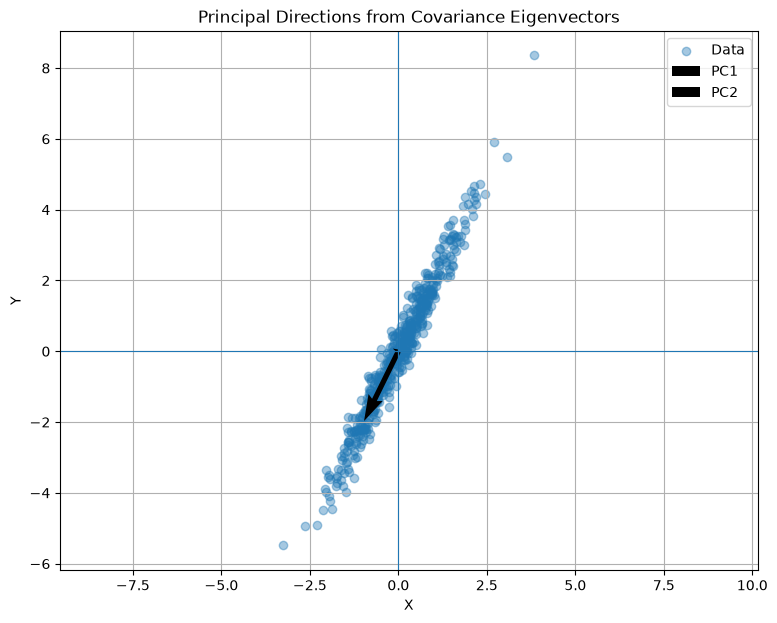

In [17]:
plt.figure(figsize=(9, 7))

plt.scatter(
    centred[:, 0],
    centred[:, 1],
    alpha=0.4,
    label="Data"
)

# Scale eigenvectors by their eigenvalues
scale1 = np.sqrt(eigenvalues[0])
scale2 = np.sqrt(eigenvalues[1])

plt.quiver(
    0, 0,
    pc1[0] * scale1,
    pc1[1] * scale1,
    angles="xy",
    scale_units="xy",
    scale=1,
    linewidth=3,
    label="PC1"
)

plt.quiver(
    0, 0,
    pc2[0] * scale2,
    pc2[1] * scale2,
    angles="xy",
    scale_units="xy",
    scale=1,
    linewidth=3,
    label="PC2"
)

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel("X")
plt.ylabel("Y")

plt.title("Principal Directions from Covariance Eigenvectors")

plt.legend()
plt.grid(True)
plt.axis("equal")

plt.show()

In [18]:
print("Eigenvalues:")
print(eigenvalues)

print("\nPC1 has the largest eigenvalue:")
print(eigenvalues[0] > eigenvalues[1])

Eigenvalues:
[4.82074548+0.j 0.0303913 +0.j]

PC1 has the largest eigenvalue:
True


In [19]:
U, s, Vt = np.linalg.svd(
    centred,
    full_matrices=False
)

print("U shape :", U.shape)
print("s shape :", s.shape)
print("Vt shape:", Vt.shape)

U shape : (500, 2)
s shape : (2,)
Vt shape: (2, 2)


In [20]:
svd_pc1 = Vt[0, :]
svd_pc2 = Vt[1, :]

print("SVD PC1:")
print(svd_pc1)

print("\nSVD PC2:")
print(svd_pc2)

SVD PC1:
[-0.44119729 -0.89741013]

SVD PC2:
[ 0.89741013 -0.44119729]


In [21]:
pc1_similarity = abs(np.dot(pc1, svd_pc1))
pc2_similarity = abs(np.dot(pc2, svd_pc2))

print("PC1 direction similarity:", pc1_similarity)
print("PC2 direction similarity:", pc2_similarity)

PC1 direction similarity: 1.0000000000000002
PC2 direction similarity: 1.0


In [22]:
print("PC1 matches:")
print(np.isclose(pc1_similarity, 1.0))

print("\nPC2 matches:")
print(np.isclose(pc2_similarity, 1.0))

PC1 matches:
True

PC2 matches:
True


In [23]:
svd_eigenvalues = s**2 / (len(centred) - 1)

print("Eigenvalues from covariance matrix:")
print(eigenvalues)

print("\nEigenvalues calculated from SVD:")
print(svd_eigenvalues)

print("\nDo they match?")
print(np.allclose(eigenvalues, svd_eigenvalues))

Eigenvalues from covariance matrix:
[4.82074548+0.j 0.0303913 +0.j]

Eigenvalues calculated from SVD:
[4.82074548 0.0303913 ]

Do they match?
True


In [24]:
projected_1d = centred @ pc1

print("Original data shape:")
print(centred.shape)

print("\nProjected data shape:")
print(projected_1d.shape)

Original data shape:
(500, 2)

Projected data shape:
(500,)


d:\AI ML Internship\.venv\Lib\site-packages\matplotlib\cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\AI ML Internship\.venv\Lib\site-packages\matplotlib\collections.py:205: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


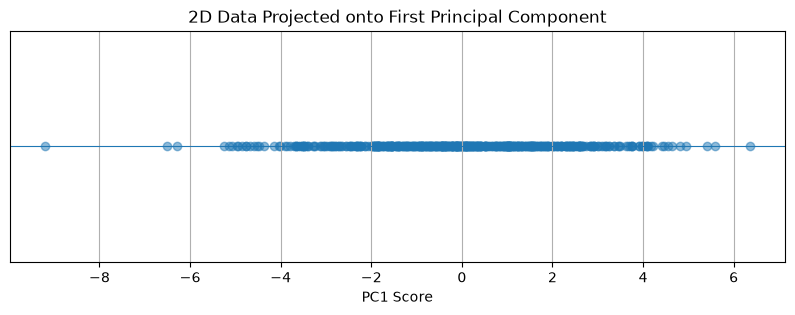

In [25]:
plt.figure(figsize=(10, 3))

plt.scatter(
    projected_1d,
    np.zeros_like(projected_1d),
    alpha=0.5
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("PC1 Score")
plt.title("2D Data Projected onto First Principal Component")

plt.yticks([])

plt.grid(True)

plt.show()

In [26]:
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

pc1_variance = explained_variance_ratio[0]

print(f"PC1 variance retained: {pc1_variance * 100:.2f}%")

PC1 variance retained: 99.37+0.00j%


In [27]:
print("Explained variance:")
print(f"PC1: {explained_variance_ratio[0] * 100:.2f}%")
print(f"PC2: {explained_variance_ratio[1] * 100:.2f}%")

print(
    f"\nTotal: "
    f"{np.sum(explained_variance_ratio) * 100:.2f}%"
)

Explained variance:
PC1: 99.37+0.00j%
PC2: 0.63+0.00j%

Total: 100.00+0.00j%


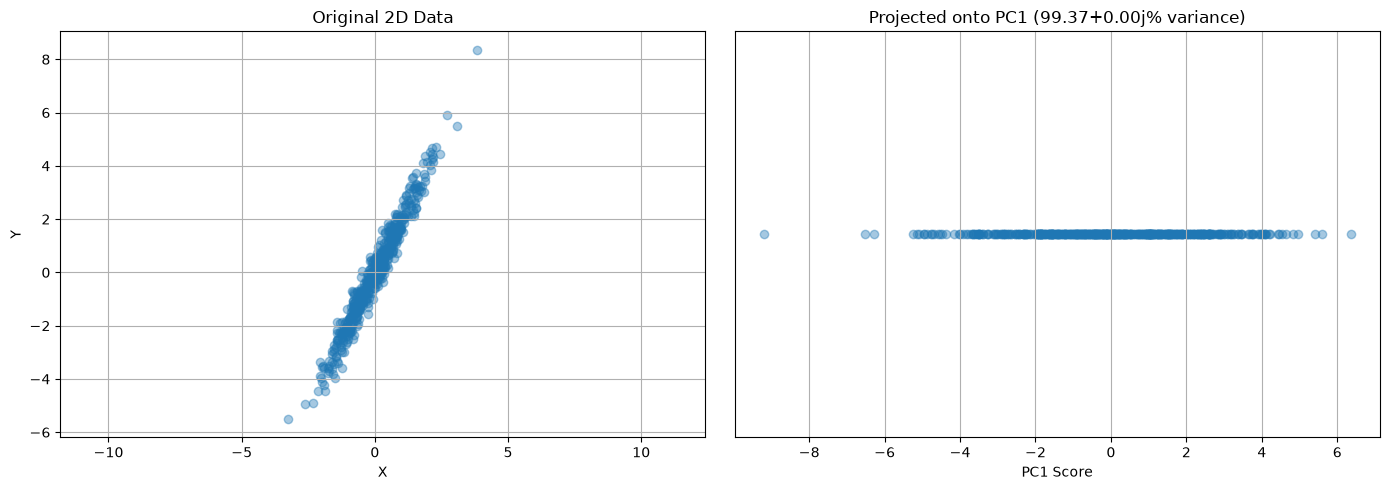

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original
axes[0].scatter(
    centred[:, 0],
    centred[:, 1],
    alpha=0.4
)

axes[0].set_title("Original 2D Data")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")
axes[0].grid(True)
axes[0].axis("equal")

# 1D
axes[1].scatter(
    projected_1d,
    np.zeros_like(projected_1d),
    alpha=0.4
)

axes[1].set_title(
    f"Projected onto PC1 "
    f"({pc1_variance * 100:.2f}% variance)"
)

axes[1].set_xlabel("PC1 Score")
axes[1].set_yticks([])
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [29]:
print("=" * 60)
print("TASK 05 FINAL VERIFICATION")
print("=" * 60)

print("\nOriginal data shape:", data.shape)

print("\nCovariance matrix:")
print(cov)

print("\nEigenvalues:")
print(eigenvalues)

print("\nCovariance eigenvectors:")
print(eigenvectors)

print("\nSVD right singular vectors:")
print(Vt)

print("\nPC1 similarity:")
print(pc1_similarity)

print("PC2 similarity:")
print(pc2_similarity)

print("\nEigenvectors and SVD directions agree:")
print(
    np.isclose(pc1_similarity, 1.0)
    and np.isclose(pc2_similarity, 1.0)
)

print("\nVariance retained by PC1:")
print(f"{pc1_variance * 100:.2f}%")

print("\nOriginal dimensions:", data.shape[1])
print("Reduced dimensions:", 1)

TASK 05 FINAL VERIFICATION

Original data shape: (500, 2)

Covariance matrix:
[[0.96285794 1.89666851]
 [1.89666851 3.88827884]]

Eigenvalues:
[4.82074548+0.j 0.0303913 +0.j]

Covariance eigenvectors:
[[-0.44119729+0.j -0.89741013+0.j]
 [-0.89741013+0.j  0.44119729+0.j]]

SVD right singular vectors:
[[-0.44119729 -0.89741013]
 [ 0.89741013 -0.44119729]]

PC1 similarity:
1.0000000000000002
PC2 similarity:
1.0

Eigenvectors and SVD directions agree:
True

Variance retained by PC1:
99.37+0.00j%

Original dimensions: 2
Reduced dimensions: 1


## Final Answer

SVD and eigen-decomposition give the same principal directions because the covariance matrix of centered data is proportional to XᵀX, whose eigenvectors are the right singular vectors of X.

The singular values are related to the covariance eigenvalues by λᵢ = σᵢ²/(n−1), so both methods identify the same directions of maximum variance.